<a href="https://colab.research.google.com/github/mohansurgiri/DeepFake-Detection-Phase2/blob/main/09072026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## Phase 2: Video Forgery Detection using CNN-LSTM

First, let's import the necessary libraries and define helper functions for video preprocessing. We'll extract frames from the videos stored in your Google Drive, resize them, and create sequences for the LSTM model.

In [2]:
import os
import cv2
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# Define core constants to ensure they are always available
SEQUENCE_LENGTH = 20 # Number of frames to extract from each video
IMG_HEIGHT = 128   # Height to resize frames to
IMG_WIDTH = 128    # Width to resize frames to
NUM_CLASSES = 2    # Number of output classes (0 for real, 1 for fake)
BATCH_SIZE = 16    # Batch size for training and evaluation

# Define video directory paths based on the user's provided locations
# Ensure these paths are correct and accessible within your mounted Google Drive
REAL_VIDEOS_DIR = '/content/drive/MyDrive/VideoForgeryDetection/Real'
FAKE_VIDEOS_DIR = '/content/drive/MyDrive/VideoForgeryDetection/Fake'

print(f"Using SEQUENCE_LENGTH: {SEQUENCE_LENGTH}")
print(f"Using IMG_HEIGHT: {IMG_HEIGHT}, IMG_WIDTH: {IMG_WIDTH}")
print(f"Using NUM_CLASSES: {NUM_CLASSES}")
print(f"Using BATCH_SIZE: {BATCH_SIZE}")
print(f"Using REAL_VIDEOS_DIR: {REAL_VIDEOS_DIR}")
print(f"Using FAKE_VIDEOS_DIR: {FAKE_VIDEOS_DIR}")

Using SEQUENCE_LENGTH: 20
Using IMG_HEIGHT: 128, IMG_WIDTH: 128
Using NUM_CLASSES: 2
Using BATCH_SIZE: 16
Using REAL_VIDEOS_DIR: /content/drive/MyDrive/VideoForgeryDetection/Real
Using FAKE_VIDEOS_DIR: /content/drive/MyDrive/VideoForgeryDetection/Fake


The following function will extract frames from a video file. We'll take a fixed number of frames (`SEQUENCE_LENGTH`) and resize them to the specified `IMG_HEIGHT` and `IMG_WIDTH`.

In [4]:
def frames_extraction(video_path):
    '''
    Extracts a fixed number of frames from a video file.

    Args:
        video_path (str): The path to the video file.

    Returns:
        np.ndarray: An array of processed frames.
    '''
    frames = []
    # Open the video file
    cap = cv2.VideoCapture(video_path)

    # Calculate the interval to extract SEQUENCE_LENGTH frames
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames < SEQUENCE_LENGTH:
        # If video has fewer frames than SEQUENCE_LENGTH, repeat frames or pad
        # For simplicity, we'll just take all available frames and potentially pad later
        indices = np.arange(total_frames)
    else:
        # Extract SEQUENCE_LENGTH evenly spaced frames
        indices = np.linspace(0, total_frames - 1, SEQUENCE_LENGTH, dtype=int)

    current_frame_index = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if current_frame_index in indices:
            # Resize the frame
            frame = cv2.resize(frame, (IMG_WIDTH, IMG_HEIGHT))
            # Convert BGR to RGB (OpenCV reads in BGR by default)
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            # Normalize pixel values to [0, 1]
            frame = frame / 255.0
            frames.append(frame)
        current_frame_index += 1

    cap.release()

    # If fewer frames were extracted than SEQUENCE_LENGTH, pad with zeros or repeat last frame
    if len(frames) < SEQUENCE_LENGTH:
        # Pad with the last frame if available, otherwise with zeros
        if frames:
            last_frame = frames[-1]
            while len(frames) < SEQUENCE_LENGTH:
                frames.append(last_frame)
        else:
            # If no frames were extracted (e.g., corrupt video), return empty array
            return np.array([])

    return np.array(frames)

Now, let's load all the video paths and prepare the dataset. We'll assign labels: 0 for real videos and 1 for fake videos.

In [5]:
all_video_paths = []
all_labels = []

# Load real videos (label 0)
real_video_files = os.listdir(REAL_VIDEOS_DIR)
for video_file in real_video_files:
    if video_file.endswith(('.mp4', '.avi', '.mov', '.webm')):
        all_video_paths.append(os.path.join(REAL_VIDEOS_DIR, video_file))
        all_labels.append(0)

# Load fake videos (label 1)
fake_video_files = os.listdir(FAKE_VIDEOS_DIR)
for video_file in fake_video_files:
    if video_file.endswith(('.mp4', '.avi', '.mov', '.webm')):
        all_video_paths.append(os.path.join(FAKE_VIDEOS_DIR, video_file))
        all_labels.append(1)

# Convert to numpy arrays and explicitly cast labels to int32
all_video_paths = np.array(all_video_paths)
all_labels = np.array(all_labels, dtype=np.int32)

print(f"Found {len(all_video_paths)} videos in total.")
print(f"Number of real videos: {np.sum(all_labels == 0)}")
print(f"Number of fake videos: {np.sum(all_labels == 1)}")

# Split the data into training and testing sets
X_train_paths, X_test_paths, y_train, y_test = train_test_split(
    all_video_paths, all_labels, test_size=0.2, random_state=42, stratify=all_labels
)

print(f"Training videos: {len(X_train_paths)}")
print(f"Test videos: {len(X_test_paths)}")

Found 400 videos in total.
Number of real videos: 200
Number of fake videos: 200
Training videos: 320
Test videos: 80


We'll now create a TensorFlow `Dataset` from these paths. This approach is memory-efficient as it loads and preprocesses videos on the fly during training.

In [6]:
def preprocess_video(video_path, label):
    '''
    Wrapper function to extract frames and return as a tf.Tensor.
    '''
    video_path_str = video_path.numpy().decode('utf-8')
    frames = frames_extraction(video_path_str)

    # Ensure frames array is not empty and has the correct shape
    if frames.size == 0 or frames.shape[0] != SEQUENCE_LENGTH:
        # Handle cases where frame extraction failed or didn't produce enough frames
        # Return a tensor of zeros with the expected shape to maintain consistency
        frames_tensor = tf.zeros(shape=(SEQUENCE_LENGTH, IMG_HEIGHT, IMG_WIDTH, 3), dtype=tf.float32)
    else:
        frames_tensor = tf.convert_to_tensor(frames, dtype=tf.float32)

    # Explicitly set the shape to ensure it's known statically
    frames_tensor.set_shape([SEQUENCE_LENGTH, IMG_HEIGHT, IMG_WIDTH, 3])

    return frames_tensor, tf.convert_to_tensor(label, dtype=tf.int32)


def create_tf_dataset(video_paths, labels, batch_size, shuffle=True):
    dataset = tf.data.Dataset.from_tensor_slices((video_paths, labels))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(video_paths))

    # Define the output signature for tf.py_function
    # Tout expects a list/tuple of dtypes or tf.TensorSpec objects
    output_signature = (
        tf.TensorSpec(shape=(SEQUENCE_LENGTH, IMG_HEIGHT, IMG_WIDTH, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.int32) # Scalar label
    )

    dataset = dataset.map(lambda x, y: tf.py_function(
        preprocess_video, [x, y], Tout=output_signature), num_parallel_calls=tf.data.AUTOTUNE)

    dataset = dataset.batch(batch_size)

    # Explicitly ensure the shape of the batched tensors
    batched_video_shape = tf.TensorShape([None, SEQUENCE_LENGTH, IMG_HEIGHT, IMG_WIDTH, 3])
    batched_label_shape = tf.TensorShape([None])
    dataset = dataset.map(lambda videos, labels: (
        tf.ensure_shape(videos, batched_video_shape),
        tf.ensure_shape(labels, batched_label_shape)
    ))

    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

# Create TensorFlow datasets
train_dataset = create_tf_dataset(X_train_paths, y_train, BATCH_SIZE)
test_dataset = create_tf_dataset(X_test_paths, y_test, BATCH_SIZE, shuffle=False)

print("TensorFlow datasets created.")

# Verify a batch from the training dataset
for videos, labels in train_dataset.take(1):
    print(f"Shape of one batch of videos: {videos.shape}") # Expected: (BATCH_SIZE, SEQUENCE_LENGTH, IMG_HEIGHT, IMG_WIDTH, 3)
    print(f"Shape of one batch of labels: {labels.shape}") # Expected: (BATCH_SIZE,)
    print(f"Labels in this batch: {labels.numpy()}")

TensorFlow datasets created.
Shape of one batch of videos: (16, 20, 128, 128, 3)
Shape of one batch of labels: (16,)
Labels in this batch: [1 1 0 0 0 1 0 1 1 1 1 0 1 1 1 0]


## 2. Model Definition (CNN-LSTM)

Now, let's define the CNN-LSTM model architecture. We will use a pre-trained CNN model (e.g., MobileNetV2, VGG16, ResNet50 as suggested in your description) as a feature extractor. The features from each frame will then be fed into an LSTM layer to capture temporal information.

We'll start by defining a `build_feature_extractor` function that takes a pre-trained CNN base and prepares it for feature extraction.

In [7]:
from tensorflow.keras.applications import MobileNetV2, VGG16, VGG19, DenseNet121, ResNet50, ResNet101, ResNet152, Xception
from tensorflow.keras.layers import TimeDistributed, LSTM, Dense, Dropout, Flatten
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam

def build_feature_extractor(model_name='MobileNetV2', img_height=IMG_HEIGHT, img_width=IMG_WIDTH):
    '''
    Builds a feature extractor using a pre-trained CNN model.

    Args:
        model_name (str): Name of the pre-trained CNN model to use.
        img_height (int): Height of the input images.
        img_width (int): Width of the input images.

    Returns:
        tf.keras.Model: A feature extractor model.
    '''
    input_shape = (img_height, img_width, 3)
    if model_name == 'MobileNetV2':
        base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)
    elif model_name == 'VGG16':
        base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    elif model_name == 'VGG19':
        base_model = VGG19(weights='imagenet', include_top=False, input_shape=input_shape)
    elif model_name == 'DenseNet121':
        base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=input_shape)
    elif model_name == 'ResNet50':
        base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    elif model_name == 'ResNet101':
        base_model = ResNet101(weights='imagenet', include_top=False, input_shape=input_shape)
    elif model_name == 'ResNet152':
        base_model = ResNet152(weights='imagenet', include_top=False, input_shape=input_shape)
    elif model_name == 'Xception':
        base_model = Xception(weights='imagenet', include_top=False, input_shape=input_shape)
    else:
        raise ValueError(f"Unsupported model name: {model_name}")

    # Freeze the layers of the base model
    base_model.trainable = False

    # Add a global average pooling layer to extract features
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    feature_extractor = Model(inputs=base_model.input, outputs=x)
    return feature_extractor

print("Feature extractor builder function defined.")

Feature extractor builder function defined.


Next, we'll combine the feature extractor with an LSTM layer for sequence processing and a final Dense layer for classification.

In [8]:
from tensorflow.keras.applications import MobileNetV2, VGG16, VGG19, DenseNet121, ResNet50, ResNet101, ResNet152, Xception
from tensorflow.keras.layers import TimeDistributed, LSTM, Dense, Dropout, Flatten, Input
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam

def build_feature_extractor(model_name='MobileNetV2', img_height=IMG_HEIGHT, img_width=IMG_WIDTH):
    '''
    Builds a feature extractor using a pre-trained CNN model.

    Args:
        model_name (str): Name of the pre-trained CNN model to use.
        img_height (int): Height of the input images.
        img_width (int): Width of the input images.

    Returns:
        tf.keras.Model: A feature extractor model.
    '''
    input_shape = (img_height, img_width, 3)
    if model_name == 'MobileNetV2':
        base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)
    elif model_name == 'VGG16':
        base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    elif model_name == 'VGG19':
        base_model = VGG19(weights='imagenet', include_top=False, input_shape=input_shape)
    elif model_name == 'DenseNet121':
        base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=input_shape)
    elif model_name == 'ResNet50':
        base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    elif model_name == 'ResNet101':
        base_model = ResNet101(weights='imagenet', include_top=False, input_shape=input_shape)
    elif model_name == 'ResNet152':
        base_model = ResNet152(weights='imagenet', include_top=False, input_shape=input_shape)
    elif model_name == 'Xception':
        base_model = Xception(weights='imagenet', include_top=False, input_shape=input_shape)
    else:
        raise ValueError(f"Unsupported model name: {model_name}")

    # Freeze the layers of the base model
    base_model.trainable = False

    # Add a global average pooling layer to extract features
    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    feature_extractor = Model(inputs=base_model.input, outputs=x)
    return feature_extractor

print("Feature extractor builder function defined.")

def build_cnn_lstm_model(feature_extractor_instance,
                         sequence_length=SEQUENCE_LENGTH,
                         img_height=IMG_HEIGHT,
                         img_width=IMG_WIDTH,
                         num_classes=NUM_CLASSES):
    '''
    Builds a CNN-LSTM model for video classification.

    Args:
        feature_extractor_instance (tf.keras.Model): An already built feature extractor model.
        sequence_length (int): Number of frames in each video sequence.
        img_height (int): Height of the input images.
        img_width (int): Width of the input images.
        num_classes (int): Number of output classes (2 for real/fake).

    Returns:
        tf.keras.Model: The compiled CNN-LSTM model.
    '''
    model = Sequential([
        Input(shape=(sequence_length, img_height, img_width, 3)), # Explicit Input layer
        # Apply the feature extractor to each frame in the sequence
        TimeDistributed(feature_extractor_instance, input_shape=(img_height, img_width, 3)), # Explicitly set input_shape for TimeDistributed
        LSTM(128, return_sequences=False), # LSTM layer to process the sequence of features
        Dropout(0.5),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax') # Output layer for binary classification
    ])

    return model

# Instantiate the feature extractor once
mobilenet_feature_extractor = build_feature_extractor(model_name='MobileNetV2')

# Instantiate the model, passing the pre-built feature extractor
cnn_lstm_model = build_cnn_lstm_model(feature_extractor_instance=mobilenet_feature_extractor)

# Compile the model
cnn_lstm_model.compile(optimizer=Adam(learning_rate=0.0001),
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

print("CNN-LSTM model built and compiled successfully.")
cnn_lstm_model.summary()

Feature extractor builder function defined.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
CNN-LSTM model built and compiled successfully.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 20, 1280)       │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       721,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,987,778 (11.40 MB)

 Trainable params: 729,794 (2.78 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 3. Model Training

Now we can train the model using the prepared TensorFlow datasets.

In [ ]:
import cv2 # Needed for frames_extraction if re-defined
import numpy as np # Needed for frames_extraction if re-defined
import tensorflow as tf
import os # Needed for os.listdir and os.path.join
from sklearn.model_selection import train_test_split # Needed for X_train_paths creation

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2 # Assuming this is the chosen extractor
from tensorflow.keras.layers import TimeDistributed, LSTM, Dense, Dropout, Flatten, Input
from tensorflow.keras.models import Sequential, Model

# Define core constants at the top to ensure they are always available
SEQUENCE_LENGTH = 20 # Default, adjust if different
IMG_HEIGHT = 128   # Default, adjust if different
IMG_WIDTH = 128    # Default, adjust if different
NUM_CLASSES = 2    # Default, adjust if different
BATCH_SIZE = 16    # Default, adjust if different

# Define video directory paths based on the user's latest correction
REAL_VIDEOS_DIR = '/content/drive/MyDrive/VideoForgeryDetection/Real'
FAKE_VIDEOS_DIR = '/content/drive/MyDrive/VideoForgeryDetection/Fake'

print(f"Using SEQUENCE_LENGTH: {SEQUENCE_LENGTH}")
print(f"Using IMG_HEIGHT: {IMG_HEIGHT}, IMG_WIDTH: {IMG_WIDTH}")
print(f"Using NUM_CLASSES: {NUM_CLASSES}")
print(f"Using BATCH_SIZE: {BATCH_SIZE}")
print(f"Using REAL_VIDEOS_DIR: {REAL_VIDEOS_DIR}")
print(f"Using FAKE_VIDEOS_DIR: {FAKE_VIDEOS_DIR}")

# Conditionally re-instantiate and compile cnn_lstm_model if it's not defined
# This guards against NameError if previous cells were not run or kernel state was lost.
if 'cnn_lstm_model' not in globals():
    print("cnn_lstm_model not found, attempting to re-instantiate and compile...")

    # Re-define build_feature_extractor if not in globals (it should be from 64cfd5aa)
    if 'build_feature_extractor' not in globals():
        def build_feature_extractor(model_name='MobileNetV2', img_height=IMG_HEIGHT, img_width=IMG_WIDTH):
            input_shape = (img_height, img_width, 3)
            base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)
            base_model.trainable = False
            x = base_model.output
            x = tf.keras.layers.GlobalAveragePooling2D()(x)
            feature_extractor = Model(inputs=base_model.input, outputs=x)
            return feature_extractor

    # Re-define build_cnn_lstm_model if not in globals (it should be from 64cfd5aa)
    if 'build_cnn_lstm_model' not in globals():
        def build_cnn_lstm_model(feature_extractor_instance,
                                 sequence_length=SEQUENCE_LENGTH,
                                 img_height=IMG_HEIGHT,
                                 img_width=IMG_WIDTH,
                                 num_classes=NUM_CLASSES):
            model = Sequential([
                Input(shape=(sequence_length, img_height, img_width, 3)),
                TimeDistributed(feature_extractor_instance, input_shape=(img_height, img_width, 3)),
                LSTM(128, return_sequences=False),
                Dropout(0.5),
                Dense(64, activation='relu'),
                Dropout(0.5),
                Dense(num_classes, activation='softmax')
            ])
            return model

    mobilenet_feature_extractor = build_feature_extractor(model_name='MobileNetV2', img_height=IMG_HEIGHT, img_width=IMG_WIDTH)
    cnn_lstm_model = build_cnn_lstm_model(
        feature_extractor_instance=mobilenet_feature_extractor,
        sequence_length=SEQUENCE_LENGTH,
        img_height=IMG_HEIGHT,
        img_width=IMG_WIDTH,
        num_classes=NUM_CLASSES
    )
    cnn_lstm_model.compile(optimizer=Adam(learning_rate=0.0001),
                           loss='sparse_categorical_crossentropy',
                           metrics=['accuracy'])
    print("cnn_lstm_model re-instantiated and compiled successfully.")

# Now, handle the data arrays and datasets if they are not defined
# (These rely on the REAL_VIDEOS_DIR and FAKE_VIDEOS_DIR defined globally above)
if 'X_train_paths' not in globals() or 'y_train' not in globals() or \
   'X_test_paths' not in globals() or 'y_test' not in globals():
    print("X_train_paths, y_train, etc. not found, attempting to re-load video paths and split data...")

    all_video_paths = []
    all_labels = []

    # Load real videos (label 0)
    if os.path.exists(REAL_VIDEOS_DIR):
        real_video_files = os.listdir(REAL_VIDEOS_DIR)
        for video_file in real_video_files:
            if video_file.endswith(('.mp4', '.avi', '.mov', '.webm')):
                all_video_paths.append(os.path.join(REAL_VIDEOS_DIR, video_file))
                all_labels.append(0)
    else:
        print(f"Warning: REAL_VIDEOS_DIR not found at {REAL_VIDEOS_DIR}")

    # Load fake videos (label 1)
    if os.path.exists(FAKE_VIDEOS_DIR):
        fake_video_files = os.listdir(FAKE_VIDEOS_DIR)
        for video_file in fake_video_files:
            if video_file.endswith(('.mp4', '.avi', '.mov', '.webm')):
                all_video_paths.append(os.path.join(FAKE_VIDEOS_DIR, video_file))
                all_labels.append(1)
    else:
        print(f"Warning: FAKE_VIDEOS_DIR not found at {FAKE_VIDEOS_DIR}")

    all_video_paths = np.array(all_video_paths)
    all_labels = np.array(all_labels, dtype=np.int32)

    if len(all_video_paths) == 0:
        raise ValueError("No videos found in the specified directories. Please check REAL_VIDEOS_DIR and FAKE_VIDEOS_DIR. Ensure Google Drive is mounted and paths are correct.")

    # Split the data into training and testing sets
    X_train_paths, X_test_paths, y_train, y_test = train_test_split(
        all_video_paths, all_labels, test_size=0.2, random_state=42, stratify=all_labels
    )
    print("Video paths and labels re-loaded and split successfully.")


if 'train_dataset' not in globals() or 'test_dataset' not in globals():
    print("train_dataset or test_dataset not found, attempting to re-create datasets...")

    # Ensure frames_extraction and preprocess_video are defined (from previous cells)
    if 'frames_extraction' not in globals():
        def frames_extraction(video_path):
            frames = []
            cap = cv2.VideoCapture(video_path)
            total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            if total_frames < SEQUENCE_LENGTH:
                indices = np.arange(total_frames)
            else:
                indices = np.linspace(0, total_frames - 1, SEQUENCE_LENGTH, dtype=int)
            current_frame_index = 0
            while True:
                ret, frame = cap.read()
                if not ret:
                    break
                if current_frame_index in indices:
                    frame = cv2.resize(frame, (IMG_WIDTH, IMG_HEIGHT))
                    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                    frame = frame / 255.0
                    frames.append(frame)
                current_frame_index += 1
            cap.release()
            if len(frames) < SEQUENCE_LENGTH:
                if frames:
                    last_frame = frames[-1]
                    while len(frames) < SEQUENCE_LENGTH:
                        frames.append(last_frame)
                else:
                    return np.array([])
            return np.array(frames)

    if 'preprocess_video' not in globals():
        def preprocess_video(video_path, label):
            video_path_str = video_path.numpy().decode('utf-8')
            frames = frames_extraction(video_path_str)
            if frames.size == 0 or frames.shape[0] != SEQUENCE_LENGTH:
                frames_tensor = tf.zeros(shape=(SEQUENCE_LENGTH, IMG_HEIGHT, IMG_WIDTH, 3), dtype=tf.float32)
            else:
                frames_tensor = tf.convert_to_tensor(frames, dtype=tf.float32)
            frames_tensor.set_shape([SEQUENCE_LENGTH, IMG_HEIGHT, IMG_WIDTH, 3])
            return frames_tensor, tf.convert_to_tensor(label, dtype=tf.int32)

    if 'create_tf_dataset' not in globals():
        def create_tf_dataset(video_paths, labels, batch_size, shuffle=True):
            dataset = tf.data.Dataset.from_tensor_slices((video_paths, labels))
            if shuffle:
                dataset = dataset.shuffle(buffer_size=len(video_paths))
            output_signature = (
                tf.TensorSpec(shape=(SEQUENCE_LENGTH, IMG_HEIGHT, IMG_WIDTH, 3), dtype=tf.float32),
                tf.TensorSpec(shape=(), dtype=tf.int32)
            )
            dataset = dataset.map(lambda x, y: tf.py_function(
                preprocess_video, [x, y], Tout=output_signature), num_parallel_calls=tf.data.AUTOTUNE)
            dataset = dataset.batch(batch_size)
            batched_video_shape = tf.TensorShape([None, SEQUENCE_LENGTH, IMG_HEIGHT, IMG_WIDTH, 3])
            batched_label_shape = tf.TensorShape([None])
            dataset = dataset.map(lambda videos, labels: (
                tf.ensure_shape(videos, batched_video_shape),
                tf.ensure_shape(labels, batched_label_shape)
            ))
            dataset = dataset.prefetch(tf.data.AUTOTUNE)
            return dataset

    # Re-create datasets using the (now ensured) X_train_paths, y_train etc.
    try:
        train_dataset = create_tf_dataset(X_train_paths, y_train, BATCH_SIZE)
        test_dataset = create_tf_dataset(X_test_paths, y_test, BATCH_SIZE, shuffle=False)
        print("TensorFlow datasets re-created successfully.")
    except Exception as e:
        # Catch broader exceptions for issues during dataset creation itself
        print(f"Error re-creating TensorFlow datasets: {e}. Please check your data preprocessing functions and paths.")
        raise # Re-raise the error to stop execution

# Define callbacks
checkpoint_filepath = 'best_cnn_lstm_model.keras'
model_checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=False,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

early_stopping_callback = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
reduce_lr_on_plateau_callback = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001, verbose=1)

# Train the model
history = cnn_lstm_model.fit(
    train_dataset,
    epochs=10, # You can adjust the number of epochs
    validation_data=test_dataset,
    callbacks=[model_checkpoint_callback, early_stopping_callback, reduce_lr_on_plateau_callback]
)

print("Model training complete.")

Using SEQUENCE_LENGTH: 20
Using IMG_HEIGHT: 128, IMG_WIDTH: 128
Using NUM_CLASSES: 2
Using BATCH_SIZE: 16
Using REAL_VIDEOS_DIR: /content/drive/MyDrive/VideoForgeryDetection/Real
Using FAKE_VIDEOS_DIR: /content/drive/MyDrive/VideoForgeryDetection/Fake
cnn_lstm_model not found, attempting to re-instantiate and compile...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


cnn_lstm_model re-instantiated and compiled successfully.
X_train_paths, y_train, etc. not found, attempting to re-load video paths and split data...
Video paths and labels re-loaded and split successfully.
train_dataset or test_dataset not found, attempting to re-create datasets...
TensorFlow datasets re-created successfully.
Epoch 1/10


## 4. Evaluation and Visualization

Let's plot the training history and evaluate the model's performance.

NameError: name 'history' is not defined

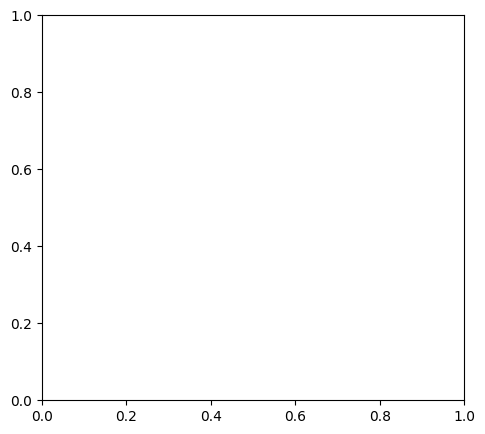

In [ ]:
import matplotlib.pyplot as plt

# Plot training history
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Evaluate the model on the test set
loss, accuracy = cnn_lstm_model.evaluate(test_dataset)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")